# What Do the Writer Models Actually Produce?

Before asking how evaluators judge cover letters (notebooks 2 and 3), this notebook asks
the more basic question: **what does each of the 11 writer models actually write?** Length,
readability, tone, emotional register, semantic fit to the job ad, vocabulary, topical
emphasis, and consistency across candidates — purely as writing-style facts about each
model, independent of who's judging them.

**Contents:**
1. Length & surface structure
2. Language complexity (readability, vocabulary richness)
3. Sentiment & affect
4. Emotion profile
5. Semantic fit to the job description
6. Do models adapt their writing to candidate quality?
7. Vocabulary and topical fingerprints (keyness, Empath)
8. Are models consistent across candidates?
9. Key takeaways


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
%matplotlib inline
plt.rcParams["figure.dpi"] = 130
sns.set_theme(style="whitegrid")

from aggregate_plots import MODEL_DISPLAY, RAW_WRITERS

CL_DIR = "output_plots/cl_features_no_gemini2"

df = pd.read_parquet("output_eval/cl_features_no_gemini2.parquet")
df["Tier"] = df["CV_Idx"].apply(lambda x: "High-Fit" if x <= 25 else "Moderate-Fit")

print(f"{len(df):,} letters | {df['Job_ID'].nunique()} jobs | "
      f"{df['Writer'].nunique()} writers | {df['CV_Idx'].nunique()} CVs/writer/job")


5,500 letters | 10 jobs | 11 writers | 50 CVs/writer/job


---
## 1. Length & Surface Structure


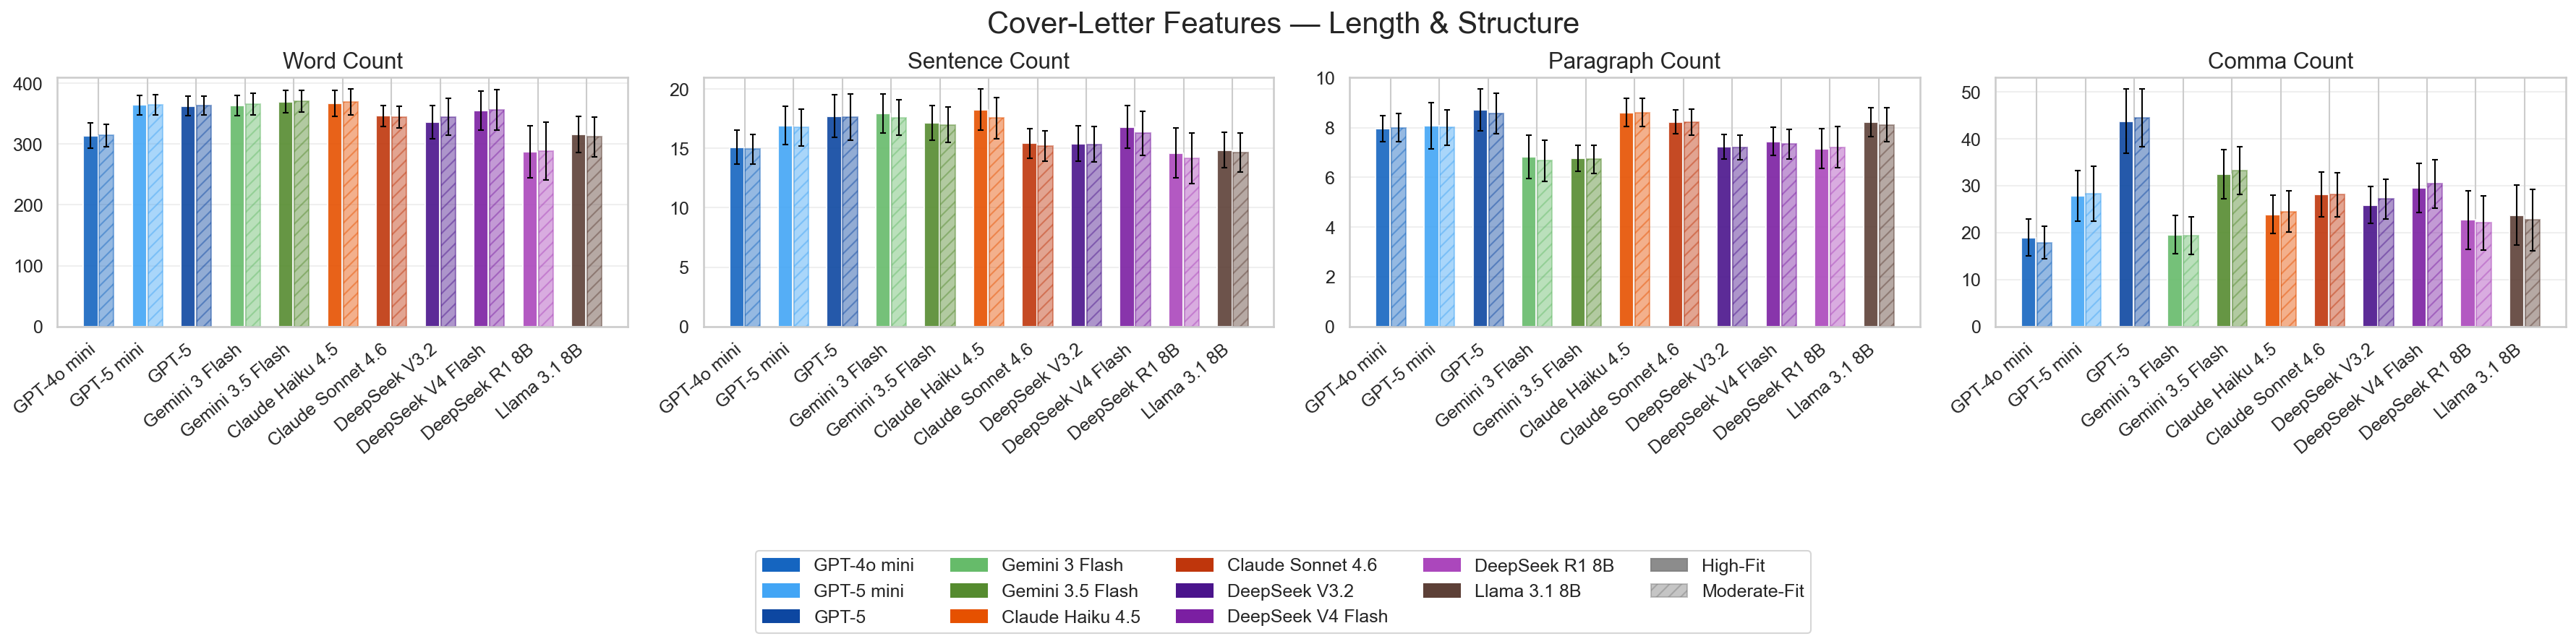

In [2]:
display(Image(f"{CL_DIR}/cl_features_length_structure.png", width=1200))

Word count, sentence count, paragraph count, and comma use. Models vary noticeably in
verbosity — some consistently write much longer letters than others, regardless of the
candidate. Tier (High-Fit vs. Moderate-Fit) differences within a model are generally small
(quantified in §6): length is mostly a fixed model style, not something a model adapts
based on how strong the candidate is.


---
## 2. Language Complexity


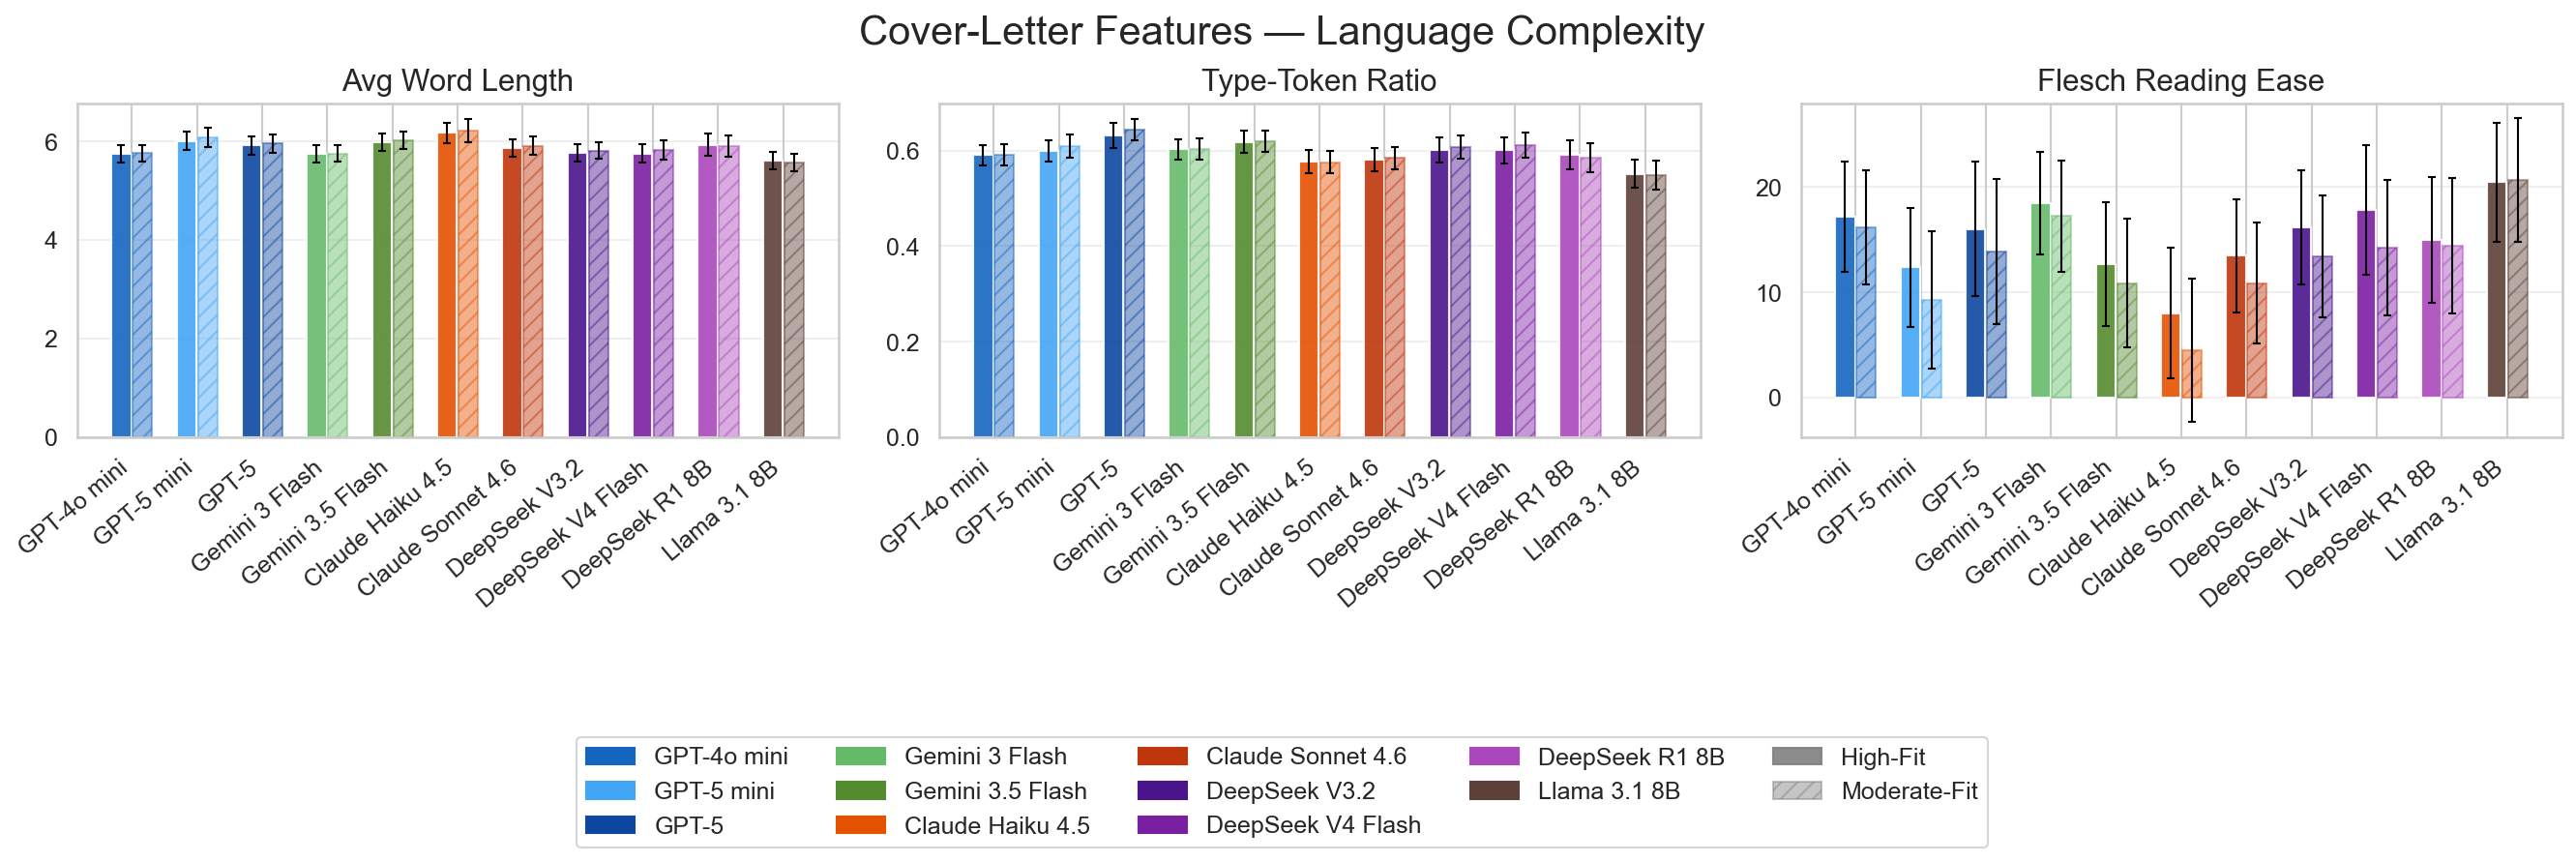

In [3]:
display(Image(f"{CL_DIR}/cl_features_language_complexity.png", width=1200))

Average word length and type-token ratio (TTR) proxy **vocabulary richness**; Flesch
Reading Ease measures **readability**. Notebook 2 shows these two axes are in tension
within a writer (a model that uses longer words tends to score lower on readability) —
Claude Haiku 4.5 sits at one extreme (longest words, hardest to read) and Llama 3.1 8B at
the other (shortest words, easiest to read).

> **Flesch Reading Ease** is computed from average sentence length and average syllables
> per word. **Higher = easier to read, lower = harder.** Rough bands: 90-100 very easy
> (simple/children's text), 60-70 plain English understood by most adults, 30-50 fairly
> difficult/academic, 0-30 very difficult/dense.


---
## 3. Sentiment & Affect


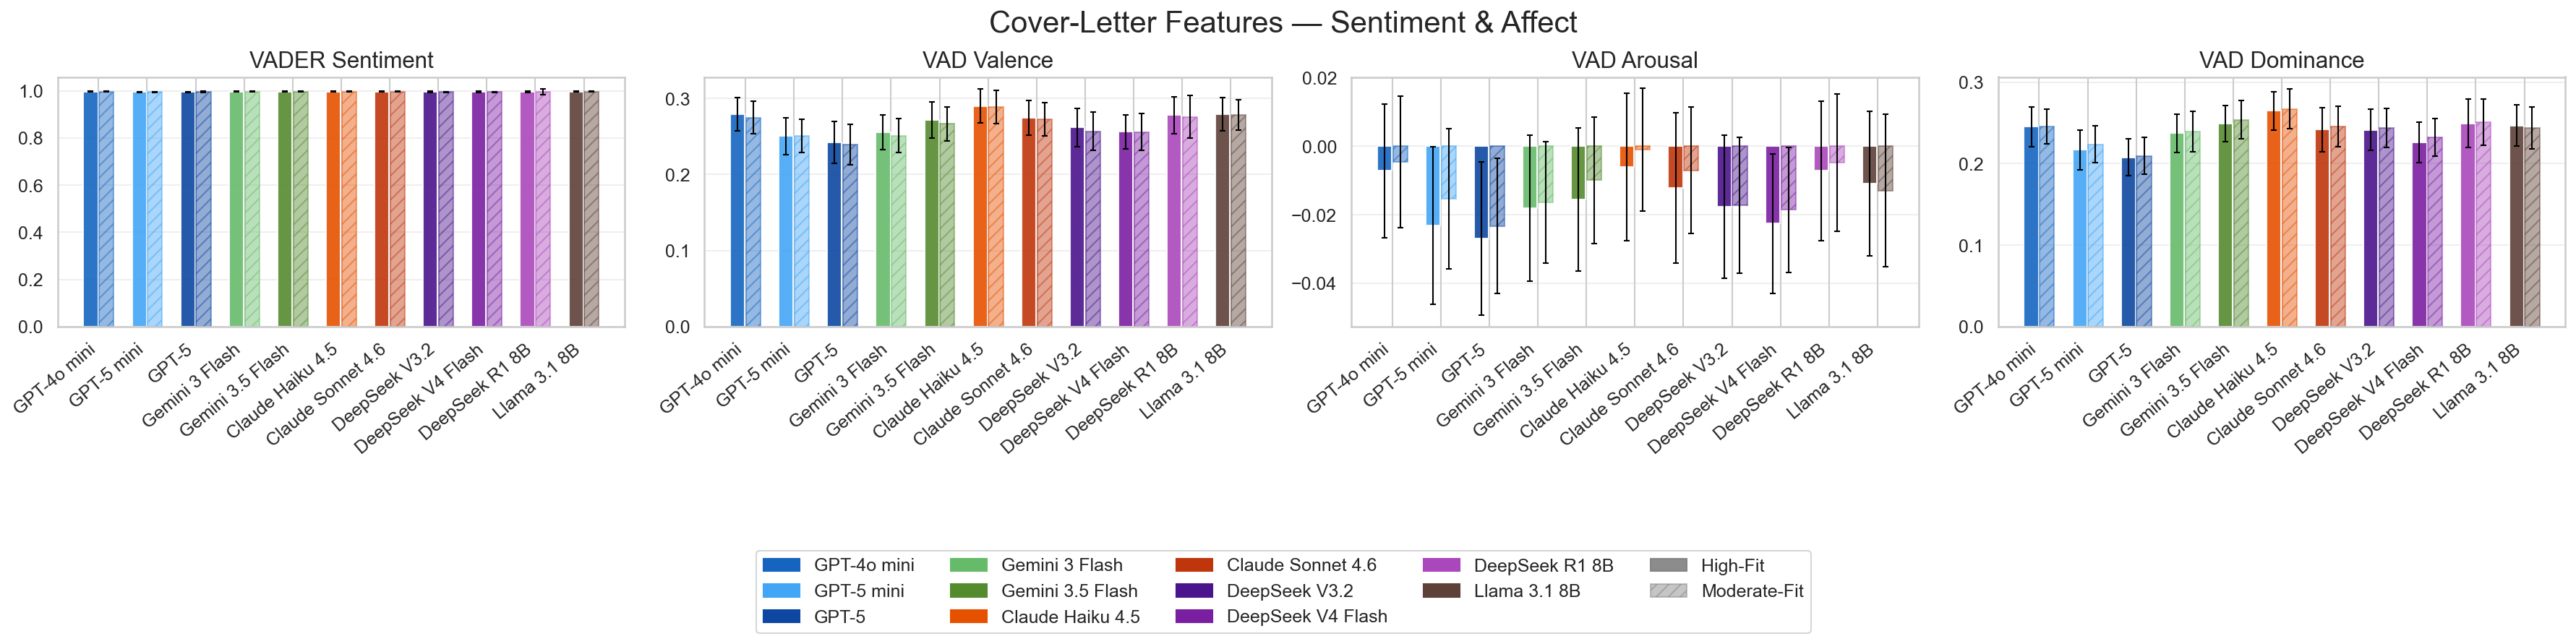

In [4]:
display(Image(f"{CL_DIR}/cl_features_sentiment_affect.png", width=1200))

- **VADER compound** and **VAD Valence** are both near-ceiling for every model — cover
  letters are uniformly positive, so this dimension does not discriminate between writers.
- **VAD Arousal** (energy/intensity) and **VAD Dominance** (assertiveness) show more
  spread, and are the two affect dimensions that actually matter downstream (notebook 2).

> **VAD (Valence-Arousal-Dominance)** is a dimensional emotion model — each axis is a
> continuous scale rather than a discrete emotion label:
> - **Valence** — positive vs. negative tone (high = "delighted", low = "disappointed").
>   Saturated/uninformative here since cover letters are uniformly positive.
> - **Arousal** — energy/intensity independent of polarity (high = "thrilled", low =
>   "content"). Distinguishes a calm-positive letter from an energetic-positive one.
> - **Dominance** — control/confidence conveyed (high = "I will deliver", low = "I would
>   hope to"). The most discriminating of the three.


---
## 4. Emotion Profile


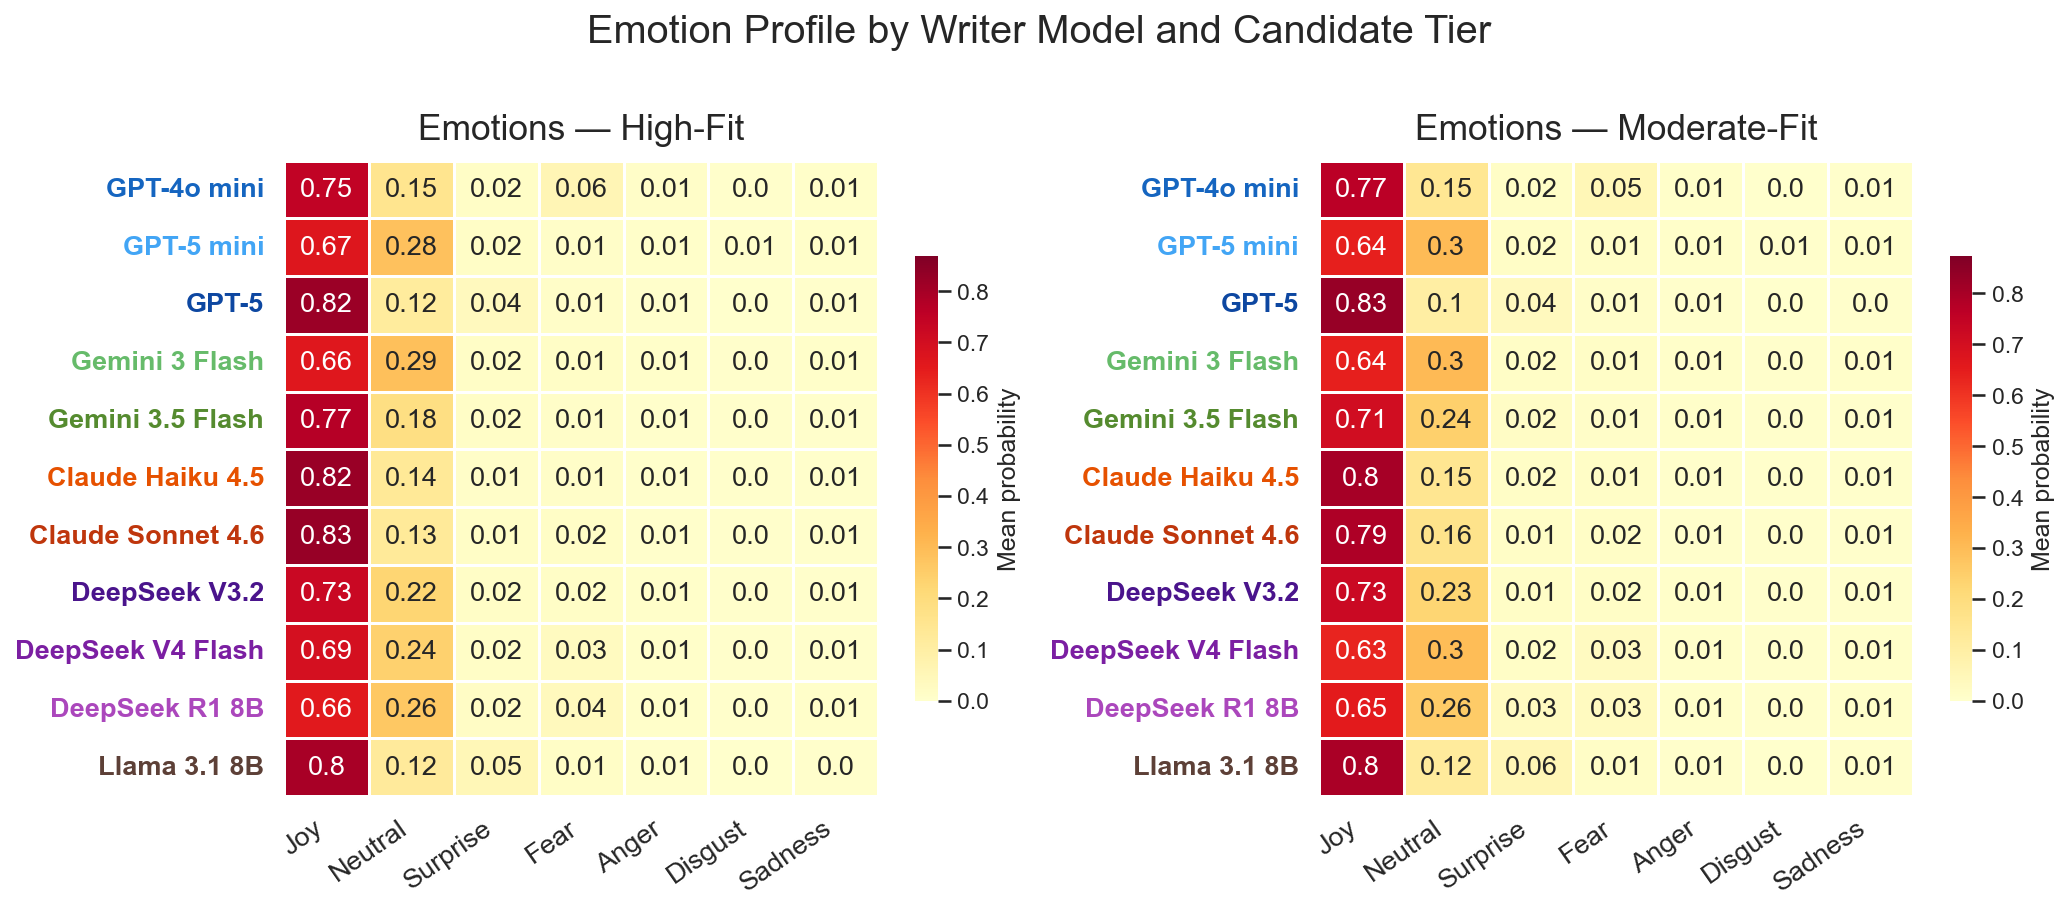

In [5]:
display(Image(f"{CL_DIR}/cl_features_emotions_heatmap.png", width=1200))

Mean emotion probability by model and tier. **Joy** and **Neutral** dominate, as expected
for professional writing, and trade off against each other almost one-for-one (notebook 2)
— a letter is either warm or measured, rarely both. The other five emotions (surprise,
fear, anger, disgust, sadness) are present at low, mostly indistinguishable levels across
models; notebook 3 confirms they carry almost no weight in what evaluators reward either.


---
## 5. Semantic Fit to the Job Description


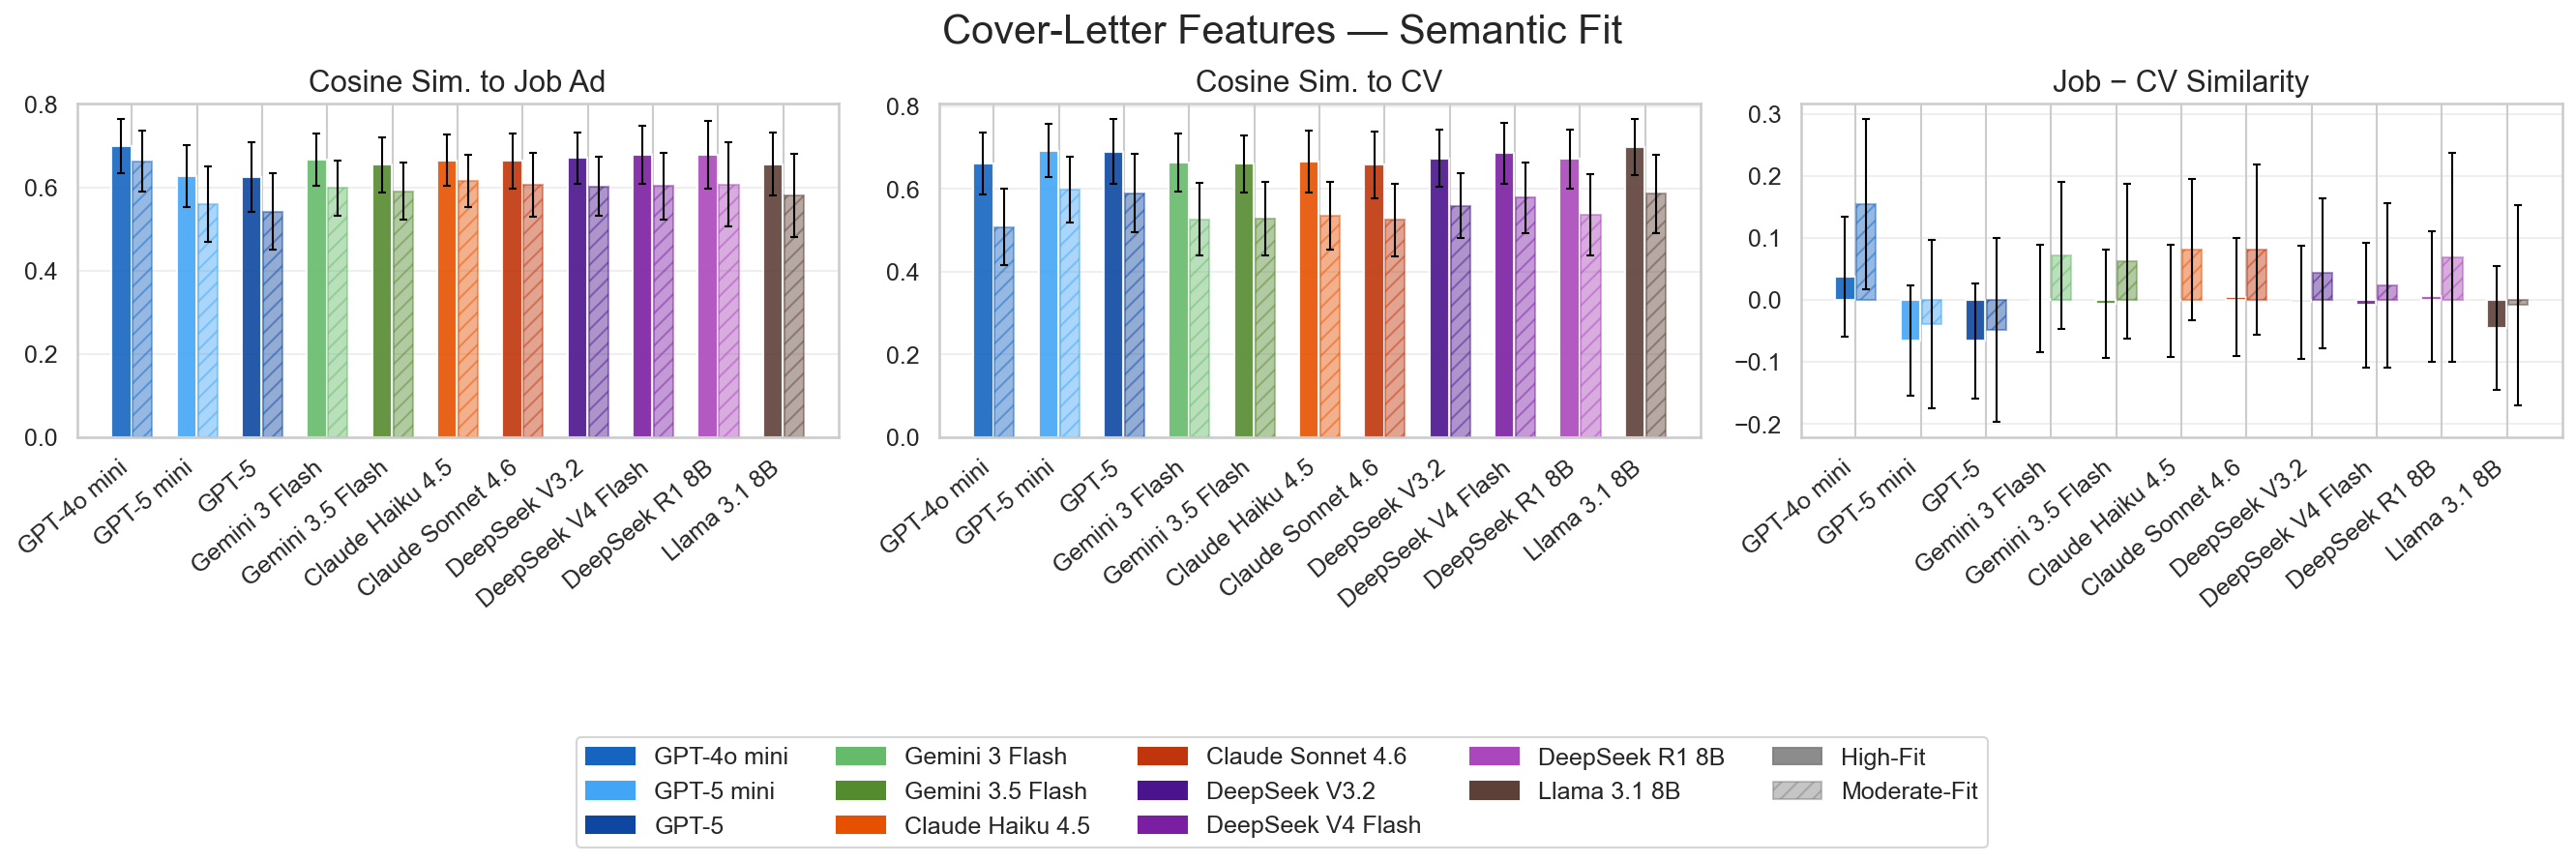

In [6]:
display(Image(f"{CL_DIR}/cl_features_semantic_fit.png", width=1200))

Cosine similarity between the cover-letter embedding and the job-description / CV
embeddings. Models differ in *which* of the two they echo more — some lean toward
mirroring the job ad, others toward mirroring the CV (notebook 2 makes this split
explicit). Note this is measured on the **produced letter**, so it's partly a writer
choice, not a pure candidate-fit signal — notebook 3 introduces a writer-independent
version of "genuine fit" (CV-to-job cosine similarity, computed before any letter exists)
to separate the two.


---
## 6. Do Models Adapt Their Writing to Candidate Quality?

For every writing-style feature, how *big* is the High-Fit vs. Moderate-Fit difference,
on a scale comparable across features (Cohen's d)? Semantic-fit features are excluded —
their tier effect is near-definitional (a high-fit CV is, by construction, closer to the
job, so a letter echoing it will be too), which isn't a stylistic finding.


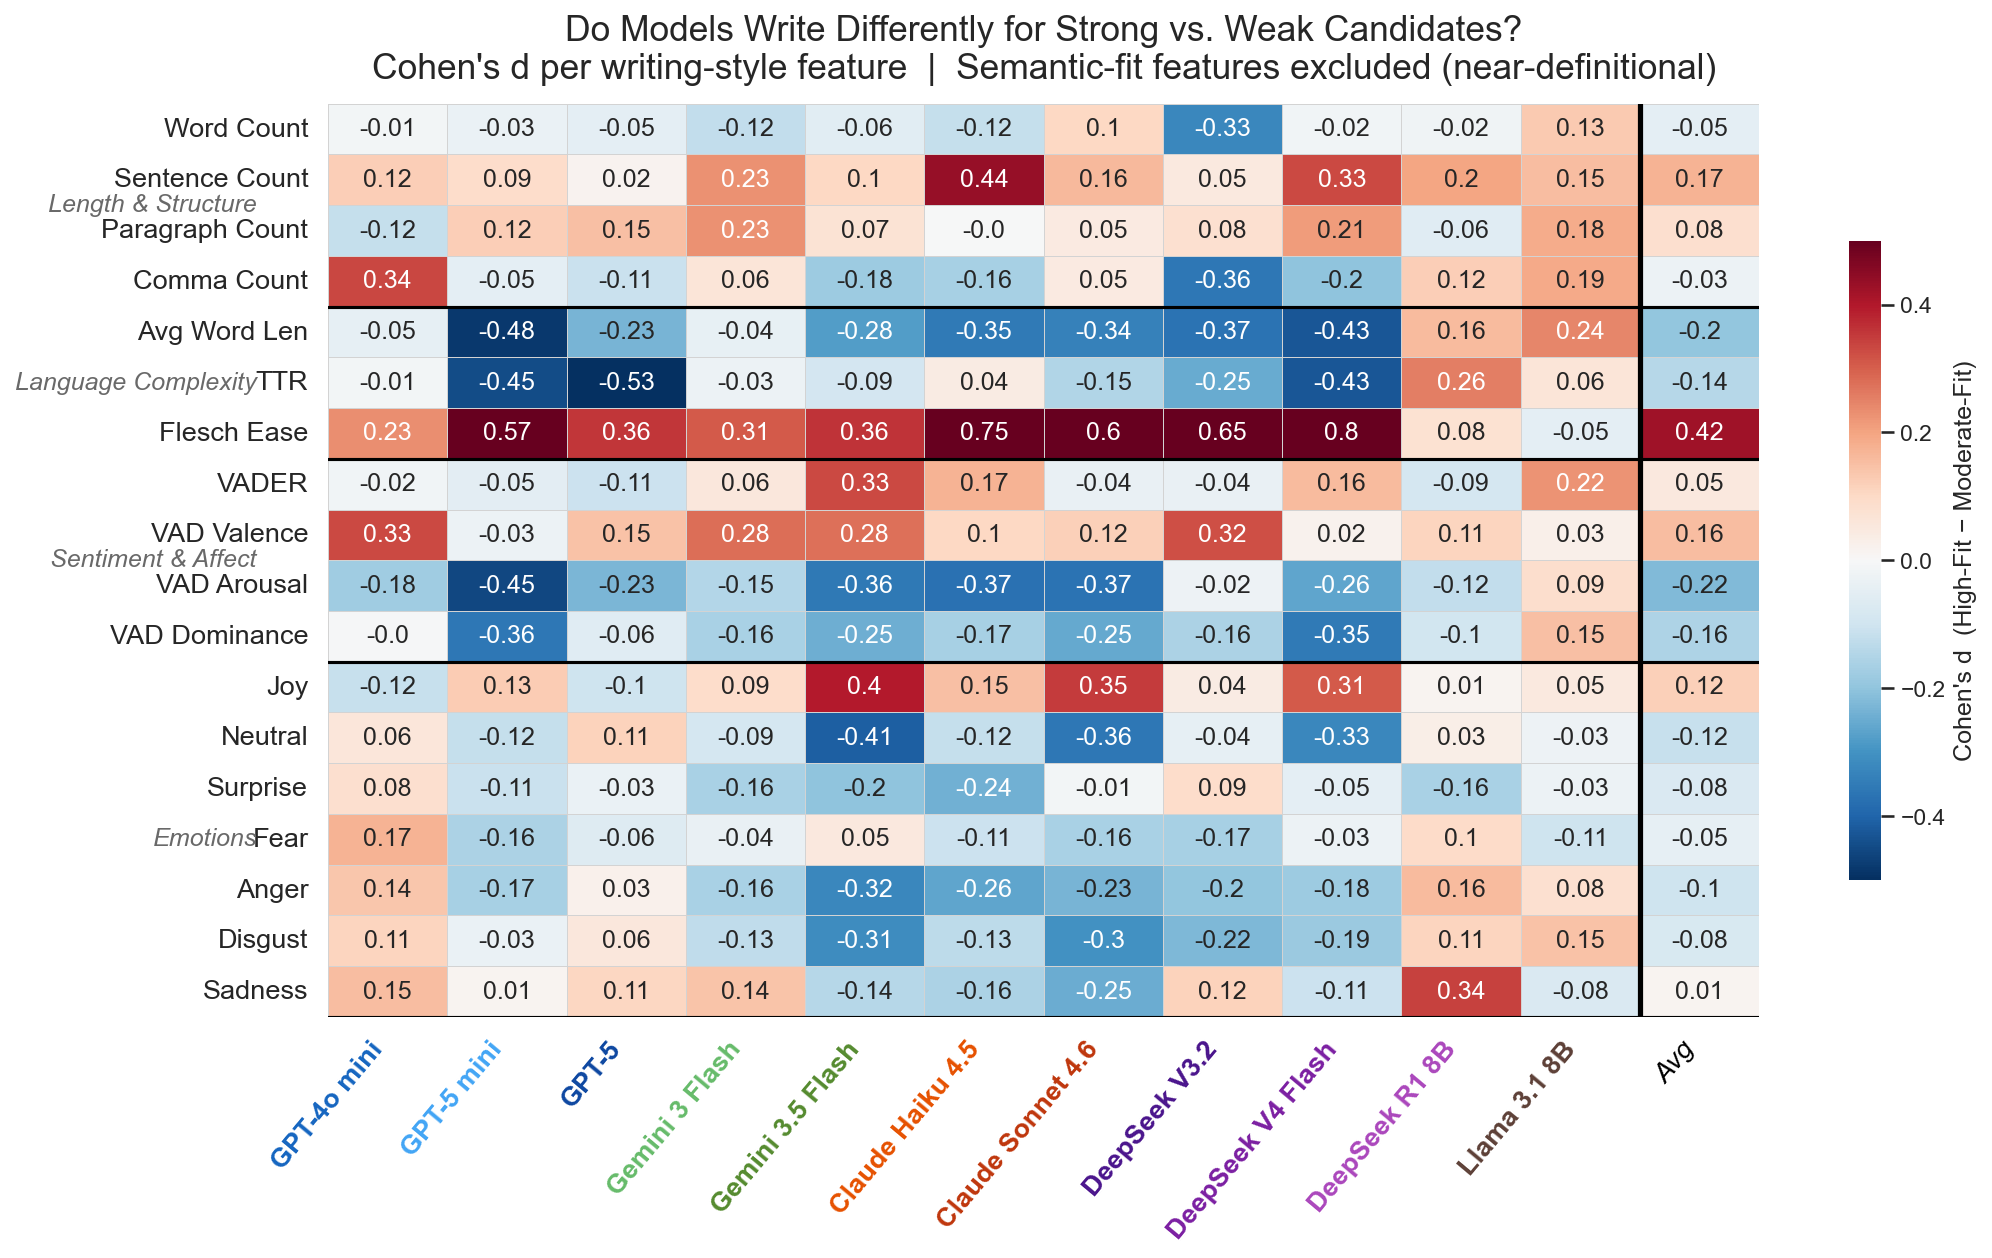

In [7]:
display(Image(f"{CL_DIR}/cl_tier_effect_heatmap.png", width=1200))

**Key finding:** style differences between high-fit and moderate-fit letters are small
overall (most |d| < 0.3), with one clear exception — **Flesch Reading Ease is consistently
higher for high-fit candidates** across almost every writer (up to d = +0.8 for some
models), i.e. **letters for stronger candidates are written in simpler, more accessible
language.** The mirror-image pattern shows up faintly too: Avg Word Length, TTR, VAD
Arousal, and VAD Dominance skew slightly negative for several models on high-fit
candidates. Emotion features show no consistent direction. Some models (e.g. GPT-5, Llama
3.1 8B) barely adapt to tier at all; others (DeepSeek, Claude models) adapt noticeably,
primarily via readability.


---
## 7. Vocabulary and Topical Fingerprints

### 7a. Keyness — Lexical Fingerprints
Lemmas statistically over-represented for each model relative to all others pooled
(G² log-likelihood ratio).


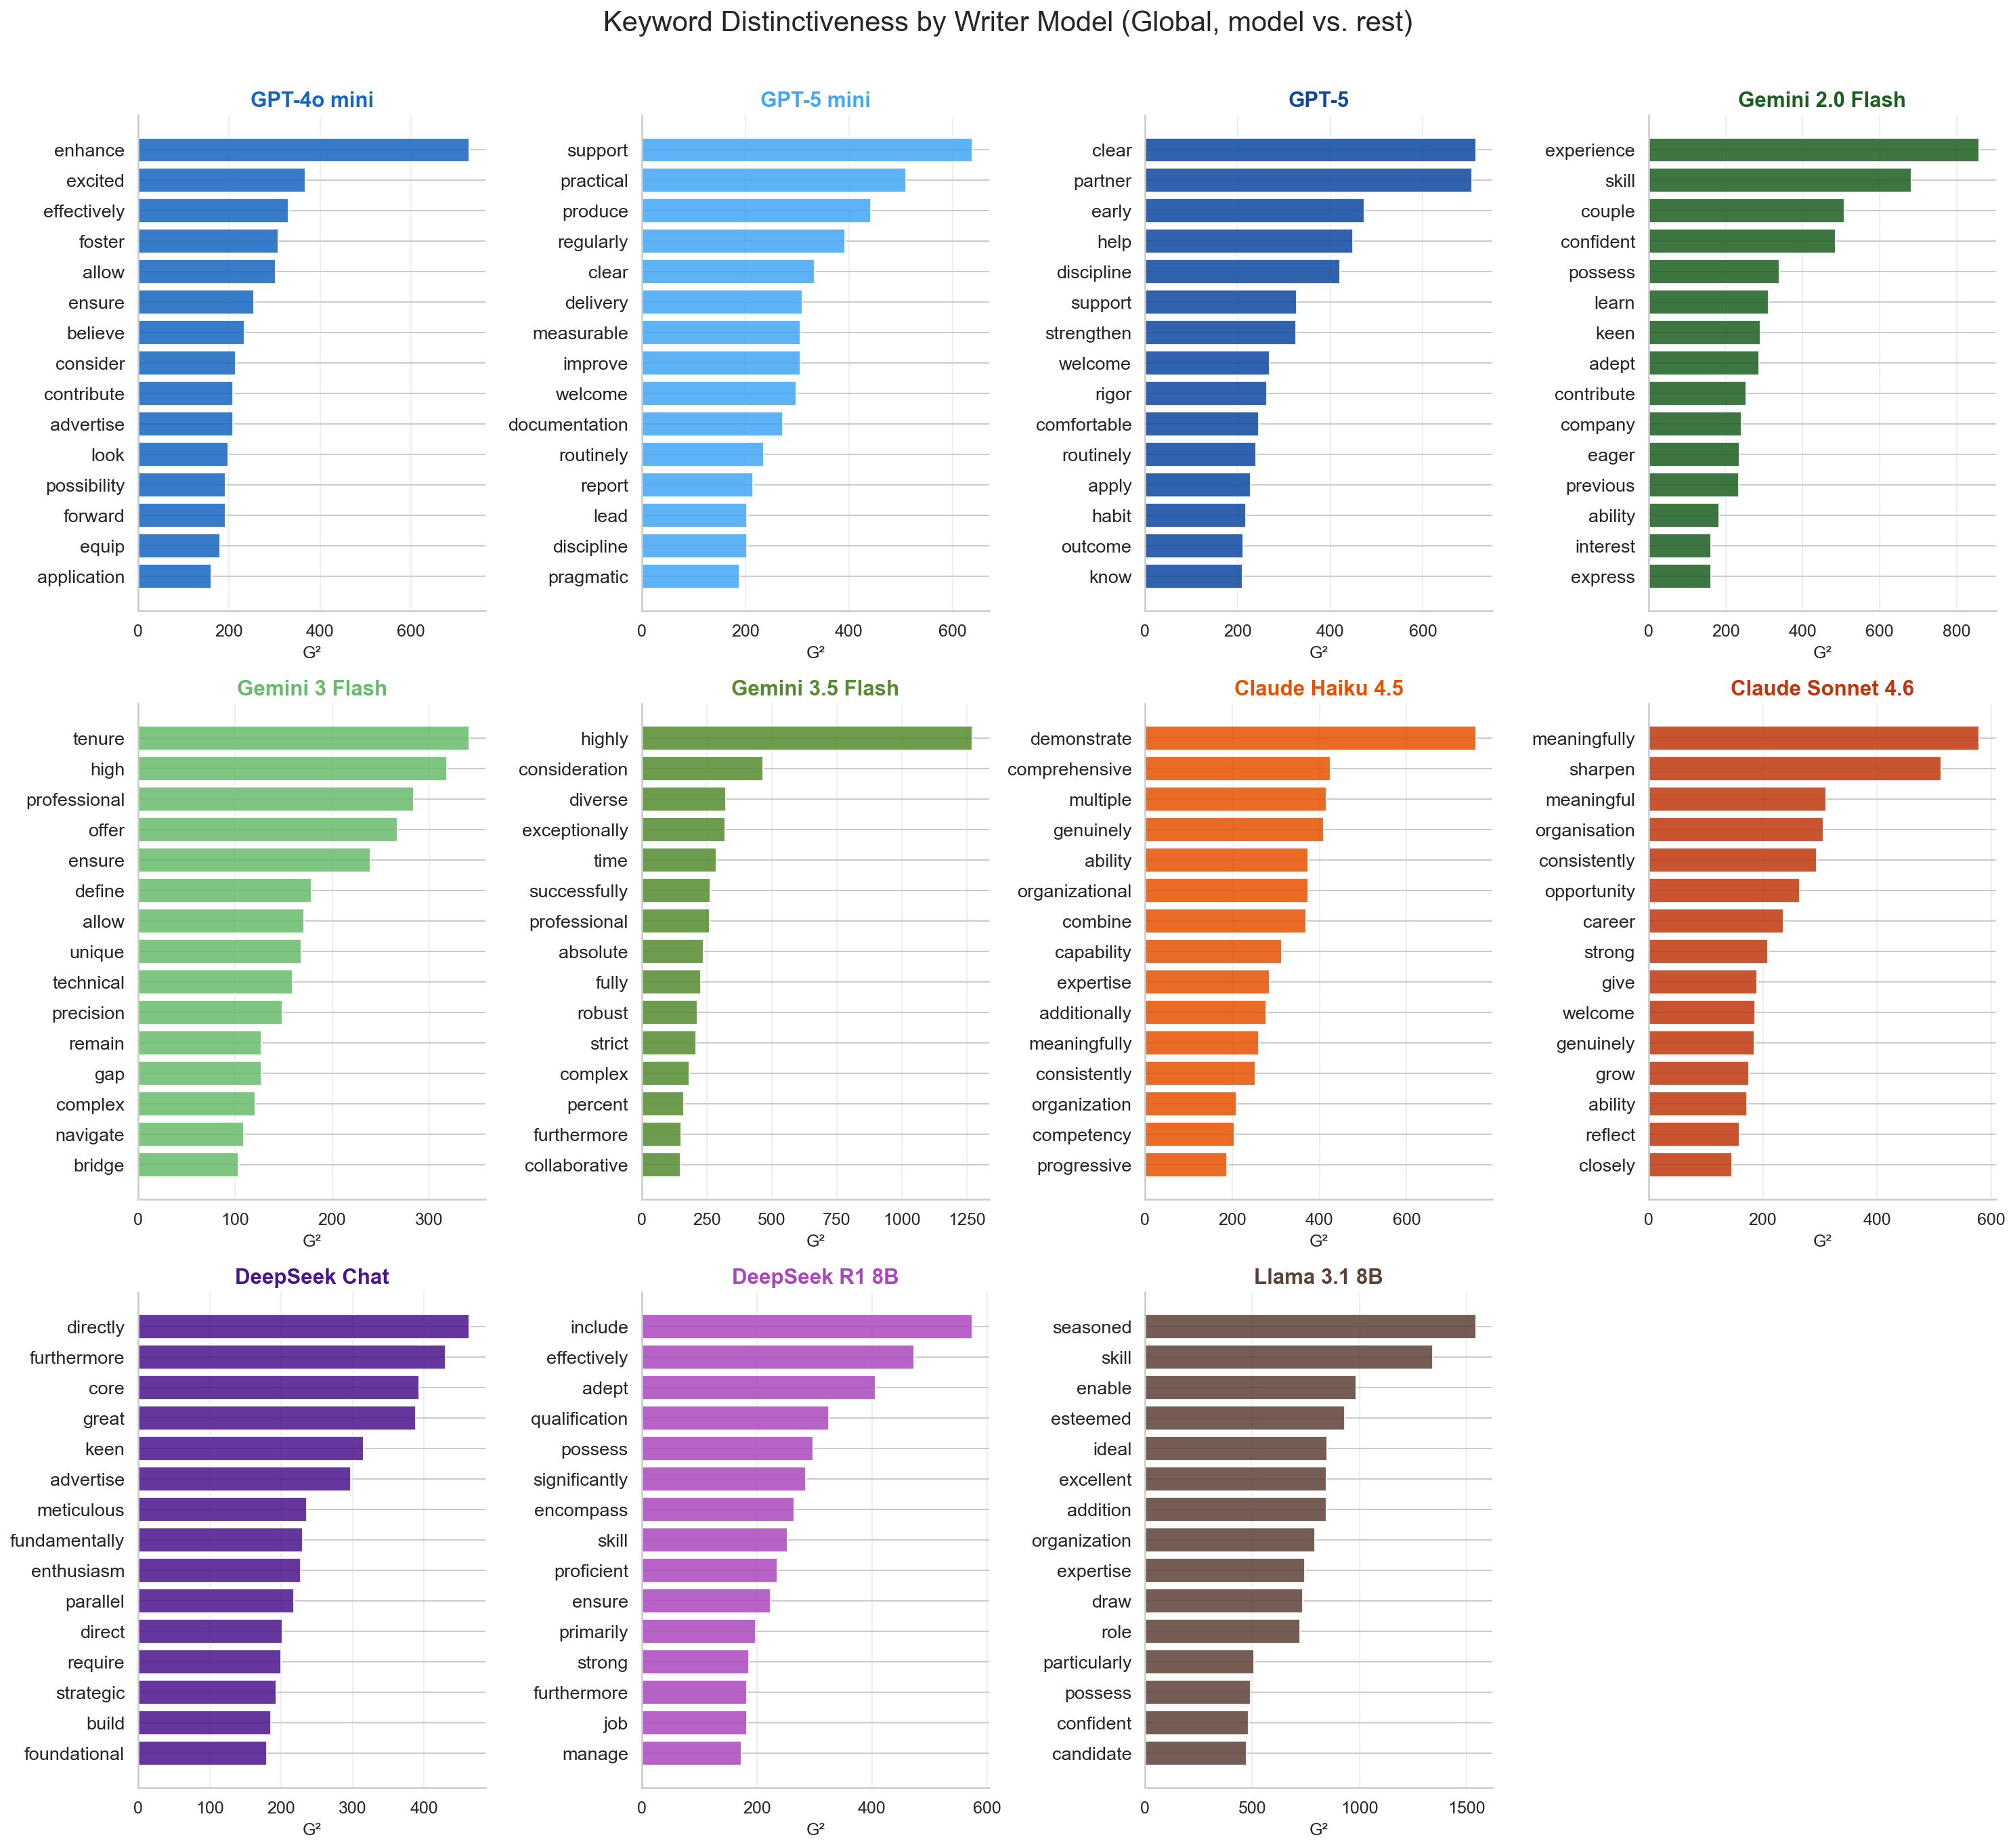

In [8]:
display(Image("output_plots/keyness/keyness_global.png"))

Each model has a distinctive vocabulary fingerprint — invisible at the embedding level
(§8 shows semantic content converges across models) but visible lemma by lemma.


### 7b. Empath — Topical Overrepresentation
For each model, Empath categories overrepresented vs. all other models pooled
(Cohen's d).


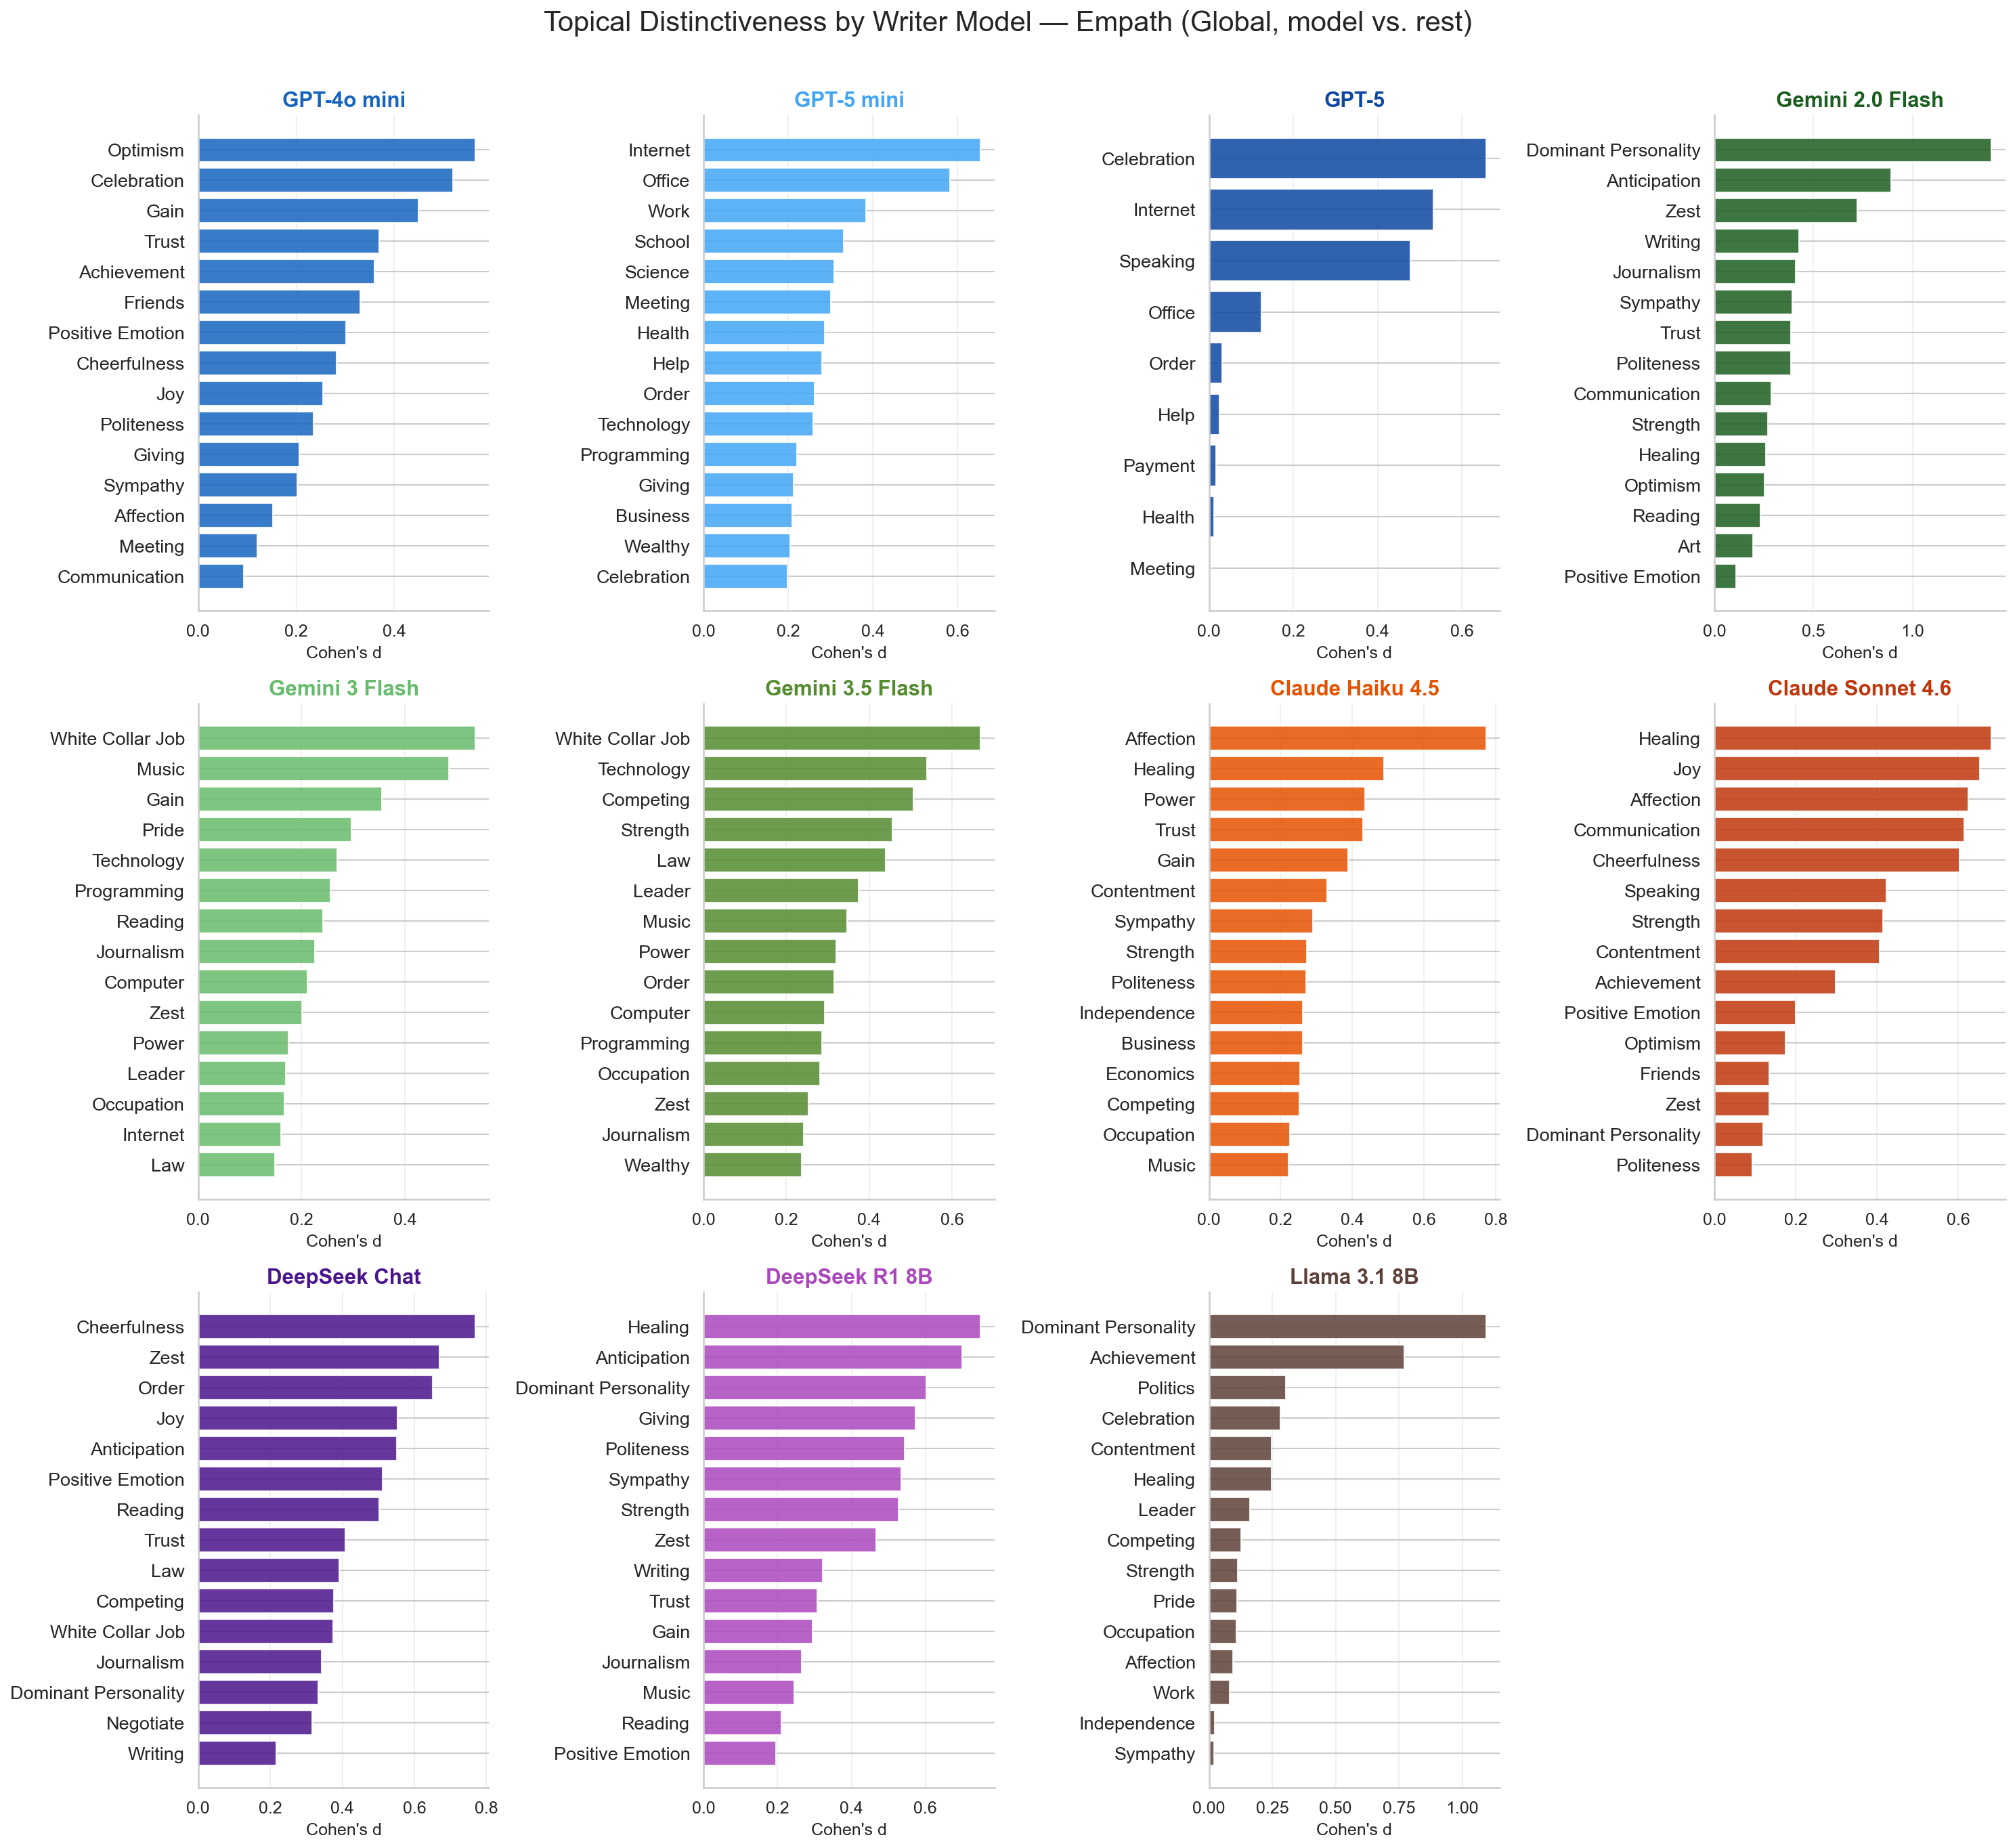

In [9]:
display(Image("output_plots/empath/empath_global.png"))

Complements keyness at the level of broader topical categories (achievement, work,
positive_emotion, etc.) rather than individual lemmas — useful for spotting thematic
emphasis a single-word analysis would miss.


---
## 8. Are Models Consistent Across Candidates?

Does a model write essentially the same letter for all 50 candidates on a given job, or
adapt to each individual CV?


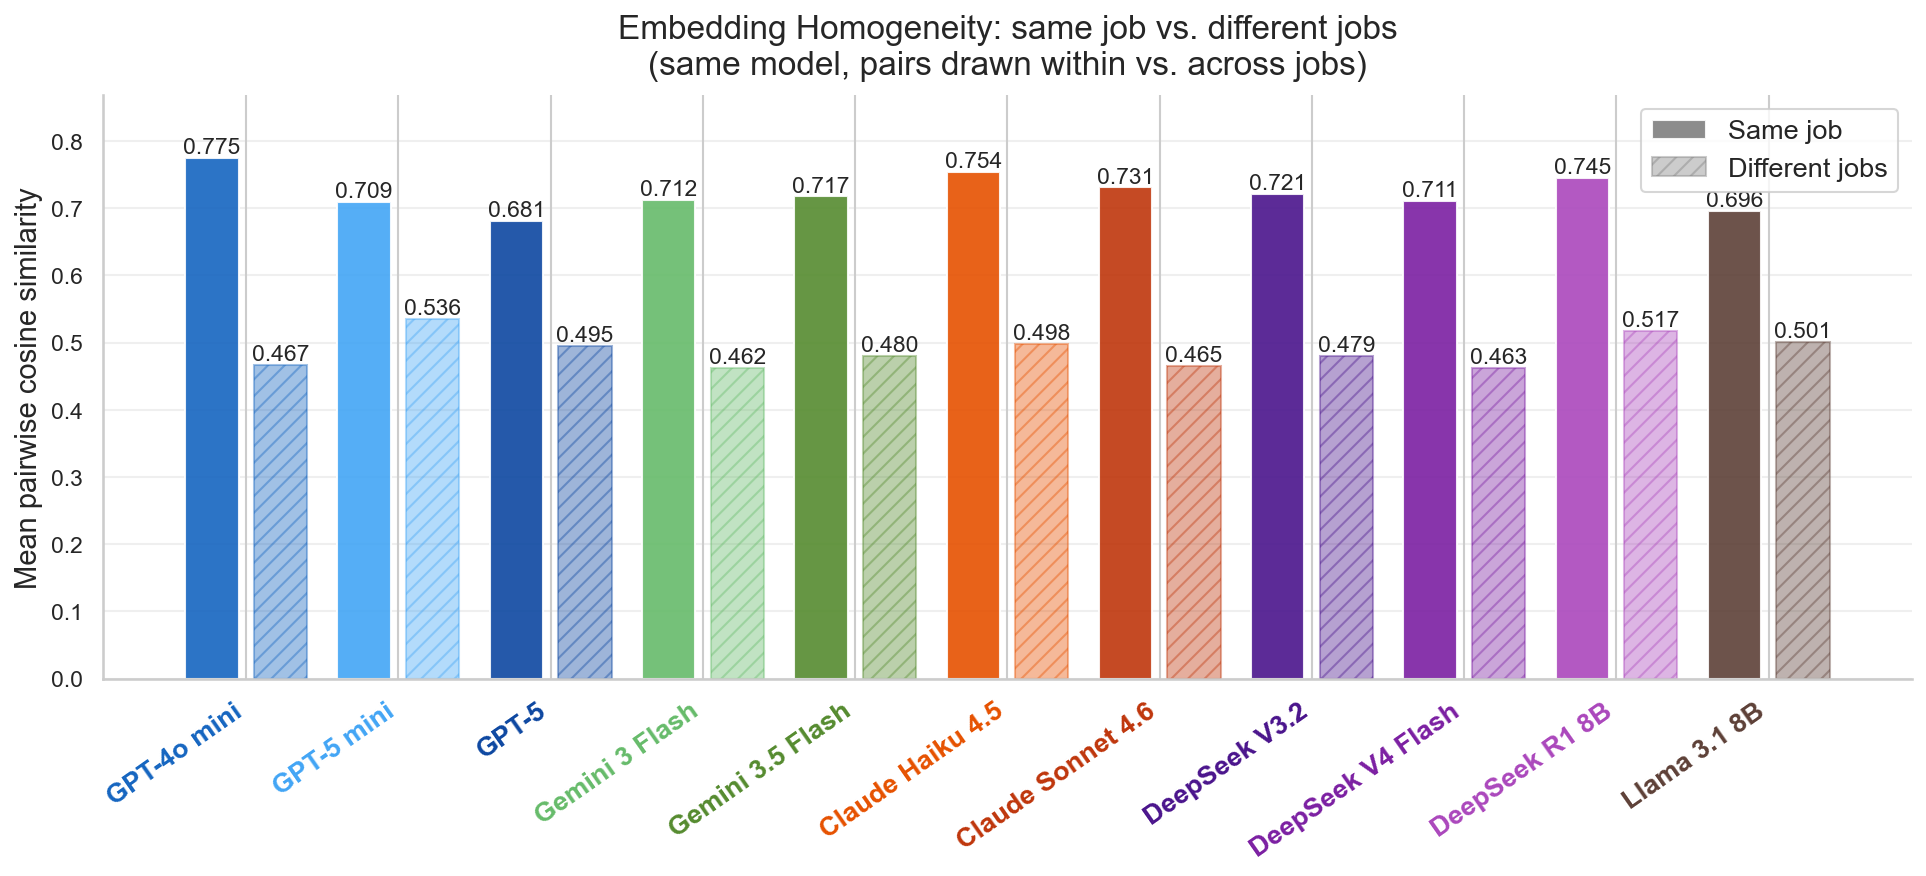

In [10]:
display(Image(f"{CL_DIR}/cl_embedding_homogeneity.png", width=1200))

In [11]:
rows = []
for writer in RAW_WRITERS:
    sub     = df[df["Writer"] == writer].copy()
    job_ids = sub["Job_ID"].to_numpy(dtype=str)
    embs    = np.array(sub["embedding"].tolist(), dtype=np.float32)
    norms   = np.linalg.norm(embs, axis=1, keepdims=True)
    embs    = embs / np.where(norms == 0, 1, norms)
    sim     = embs @ embs.T
    same    = (job_ids[:, None] == job_ids[None, :])
    n       = len(embs)
    upper   = np.triu_indices(n, k=1)
    s, mask = sim[upper], same[upper]
    rows.append({"Model":       MODEL_DISPLAY[writer],
                 "Within-job":  round(float(s[mask].mean()),  4),
                 "Cross-job":   round(float(s[~mask].mean()), 4)})

hom = (pd.DataFrame(rows).set_index("Model")
         .sort_values("Within-job", ascending=False))
hom["Gap (within − cross)"] = (hom["Within-job"] - hom["Cross-job"]).round(4)
display(hom)


,Within-job,Cross-job,Gap (within − cross)
Model,,,
GPT-4o mini,0.7750,0.4666,0.3084
Claude Haiku 4.5,0.7542,0.4979,0.2563
DeepSeek R1 8B,0.7445,0.5170,0.2275
Claude Sonnet 4.6,0.7308,0.4649,0.2659
DeepSeek V3.2,0.7215,0.4795,0.2420
Gemini 3.5 Flash,0.7174,0.4799,0.2375
Gemini 3 Flash,0.7117,0.4622,0.2495
DeepSeek V4 Flash,0.7112,0.4629,0.2483
GPT-5 mini,0.7086,0.5358,0.1728


**Key finding:** within-job similarity (0.68-0.78) is far higher than cross-job
(0.46-0.54) for every writer — the **job description** drives semantic content; models
adapt to the job, not to the individual candidate. The model with the smallest
within/cross-job gap varies least in content across different jobs; the one with the
lowest within-job similarity preserves the most letter-to-letter individuality even for
the same job.


---
## 9. Key Takeaways

| # | Finding |
|---|---|
| 1 | **Verbosity is a stable model trait**, largely independent of candidate quality. |
| 2 | **Readability and word length trade off within a writer** — longer average words go with harder-to-read prose (Claude Haiku 4.5 vs. Llama 3.1 8B mark the two extremes). |
| 3 | **Sentiment is uniformly positive** across all models — not a discriminating feature; **Arousal** and **Dominance** are, and matter more downstream (notebook 2/3). |
| 4 | **Joy and Neutral trade off almost one-for-one**; the other five emotions barely vary across models and carry little weight in evaluation (notebook 3). |
| 5 | **Semantic fit splits writers into "job-ad echoers" and "CV echoers"** — a genuine writer choice, not a pure candidate-fit signal (notebook 2/3 unpack this further). |
| 6 | **The one systematic tier adaptation**: letters for stronger candidates are written in simpler, more readable language. Most other style features barely move with candidate quality. |
| 7 | **Semantic content converges across models; lexical and topical fingerprints do not** — each model has a distinctive vocabulary invisible in embedding space. |
| 8 | **Models adapt to the job, not the candidate** — within-job similarity is far higher than cross-job similarity for every writer. |
